# Figure3 (Model Map with Resampled Texts)

In [1]:
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import defaultdict
from src.visualization import adjust, lighter
from src.ellipse import rotate, map_centrography
from matplotlib.patches import Ellipse, Rectangle
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

In [2]:
tsne_Q = pickle.load(open('data/tsne_Q.pkl', 'rb'))
modeldata = pickle.load(open('data/modeldata_1018.pkl', 'rb'))
type_color = pickle.load(open('data/color/modeltype.pkl', 'rb'))

**Data for Figure3 (a)**  
Code for the data: `fig3a_mapvariance.py`

In [3]:
# Figure3 (a)
data_fig3a = pickle.load(open('./data/fig3a_mapvariance.pkl', 'rb'))
tsne1 = data_fig3a['tsne_lss_2900_R100']
tsne2 = data_fig3a['tsne_uni_10000_R100']
tsne3 = data_fig3a['tsne_uni_2500_R100']

**Data for Figure3 (b)**  
Code for the data: `fig3b_addnew.py`

In [4]:
# Figure3 (b)
data_fig3b = pickle.load(open('./data/fig3b_addnew.pkl', 'rb'))
exist_new = data_fig3b['name']
tsne4 = rotate(data_fig3b['tsne']['2900'], ref_tsne_data=tsne_Q)

In [5]:
def get_plotdata(tsne_points, ellipses):
    plot_data = {
        'points': {
            'others': {'x': [], 'y': [], 'color': [], 'model_names': []},
            'show': {}
        },
        'ellipses': ellipses
    }
    for md in modeldata:
        model_name = md['model_name']
        model_type = md['modeltype_fig1']
        coords = tsne_points[model_name]
        if model_type == 'others':
            color = type_color['others']
            plot_data['points']['others']['x'].append(coords[0])
            plot_data['points']['others']['y'].append(coords[1])
            plot_data['points']['others']['color'].append(color)
            plot_data['points']['others']['model_names'].append(model_name)
            plot_data['ellipses'][model_name]['xy'] = coords
            plot_data['ellipses'][model_name]['color'] = color
        else:
            color = type_color[model_type]
            if model_type not in plot_data['points']['show']:
                plot_data['points']['show'][model_type] = {'x': [], 'y': [], 'color': [], 'model_names': [], 'label': model_type}
            plot_data['points']['show'][model_type]['x'].append(coords[0])
            plot_data['points']['show'][model_type]['y'].append(coords[1])
            plot_data['points']['show'][model_type]['color'].append(color)
            plot_data['points']['show'][model_type]['model_names'].append(model_name)
            plot_data['ellipses'][model_name]['xy'] = coords
            plot_data['ellipses'][model_name]['color'] = color
    return plot_data


def get_plotdata_addnew(tsne_points):
    exist_models = exist_new['existing_models']
    new_models = exist_new['new_models']

    all_plot_data = {
        'exist_points': {
            'others': {'x': [], 'y': [], 'color': [], 'shape-info': []},
            'show': defaultdict(lambda: {'x': [], 'y': [], 'color': []})
        },
        'new_points': {
            'others': {'x': [], 'y': [], 'color': [], 'shape-info': []},
            'show': defaultdict(lambda: {'x': [], 'y': [], 'color': []})
        }
    }
    for md in modeldata:
        model_name = md['model_name']
        model_type = md['modeltype_fig1']
        coords = tsne_points[model_name]

        if model_name in exist_models:
            if model_type == 'others':
                plot_data = all_plot_data['exist_points']['others']
            else:
                plot_data = all_plot_data['exist_points']['show'][model_type]
            color = type_color[model_type]
        elif model_name in new_models:
            if model_type == 'others':
                plot_data = all_plot_data['new_points']['others']
            else:
                plot_data = all_plot_data['new_points']['show'][model_type]
            color = type_color[model_type]
        plot_data['x'].append(coords[0])
        plot_data['y'].append(coords[1])
        plot_data['color'].append(color)
    return all_plot_data

p1, e1 = map_centrography(tsne1, ref_tsne_data=tsne_Q)
p2, e2 = map_centrography(tsne2, ref_tsne_data=tsne_Q)
p3, e3 = map_centrography(tsne3, ref_tsne_data=tsne_Q)
plot_data1 = get_plotdata(p1, e1)
plot_data2 = get_plotdata(p2, e2)
plot_data3 = get_plotdata(p3, e3)
plot_data4 = get_plotdata_addnew(tsne4)
plot_data5 = get_plotdata_addnew(tsne_Q)

In [6]:
def put_text(ax, x, y, text, fs=18, w='heavy', ha='center', va='center', color='black', trans=None):
    if trans is None:
        trans = ax.transAxes
    ax.text(x, y, text, fontsize=fs, fontweight=w, ha=ha, va=va, color=color, transform=trans)

def put_bg(ax):
    rect = Rectangle(
        xy=(0, 0), width=1, height=1, facecolor='gainsboro',
        linewidth=0, edgecolor='black', alpha=1, zorder=0,
        transform=ax.transAxes, clip_on=False
    )
    ax.add_patch(rect)

def put_mse(ax, value):
    x = ax.dataLim.extents[0] + ax.dataLim.extents[2] * 1.5
    y = ax.dataLim.extents[1] + ax.dataLim.extents[3] * 1.75
    put_text(ax, x, y, rf'MSE=${value}$', fs=17, w='medium', color='black', trans=ax.transData)

def scatter_and_ellipse(ax, plot_data):
    points = plot_data['points']
    ellipses = plot_data['ellipses']
    ax.scatter(
        points['others']['x'], points['others']['y'], c=points['others']['color'],
        s=2, alpha=1, zorder=1, rasterized=True
    )
    for model_type, data in points['show'].items():
        ax.scatter(
            data['x'], data['y'], c=data['color'],
            s=2, alpha=1, zorder=2, rasterized=True
        )
    for model_name, ellipse in tqdm(ellipses.items()):
        ellipse_shape = Ellipse(
            xy=ellipse['xy'],
            width=ellipse['width'],
            height=ellipse['height'],
            angle=ellipse['angle'],
            facecolor=lighter(ellipse['color'], 0.15),
            alpha=0.6,
            zorder=0,
            rasterized=True
        )
        ax.add_patch(ellipse_shape)
    ax.set_xticks([])
    ax.set_yticks([])

def scatter_newmodels(ax, plot_data):
    existing_points = plot_data['exist_points']
    new_points = plot_data['new_points']
    ax.scatter(
        existing_points['others']['x'], existing_points['others']['y'], c=existing_points['others']['color'],
        s=2, alpha=1, zorder=1, rasterized=True
    )
    for model_type, data in existing_points['show'].items():
        ax.scatter(
            data['x'], data['y'], c=data['color'],
            s=2, alpha=1, zorder=2, rasterized=True
        )
    ax.scatter(
        new_points['others']['x'], new_points['others']['y'], facecolor=new_points['others']['color'],
        marker='*', edgecolor='black', linewidths=0.5,
        s=80, alpha=1, zorder=3, rasterized=True
    )
    for model_type, data in new_points['show'].items():
        ax.scatter(
            data['x'], data['y'], facecolor=data['color'],
            marker='*', edgecolor='black', linewidths=0.5,
            s=80, alpha=1, zorder=4, rasterized=True
        )
    ax.set_xticks([])
    ax.set_yticks([])

100%|██████████| 1018/1018 [00:00<00:00, 1376.10it/s]


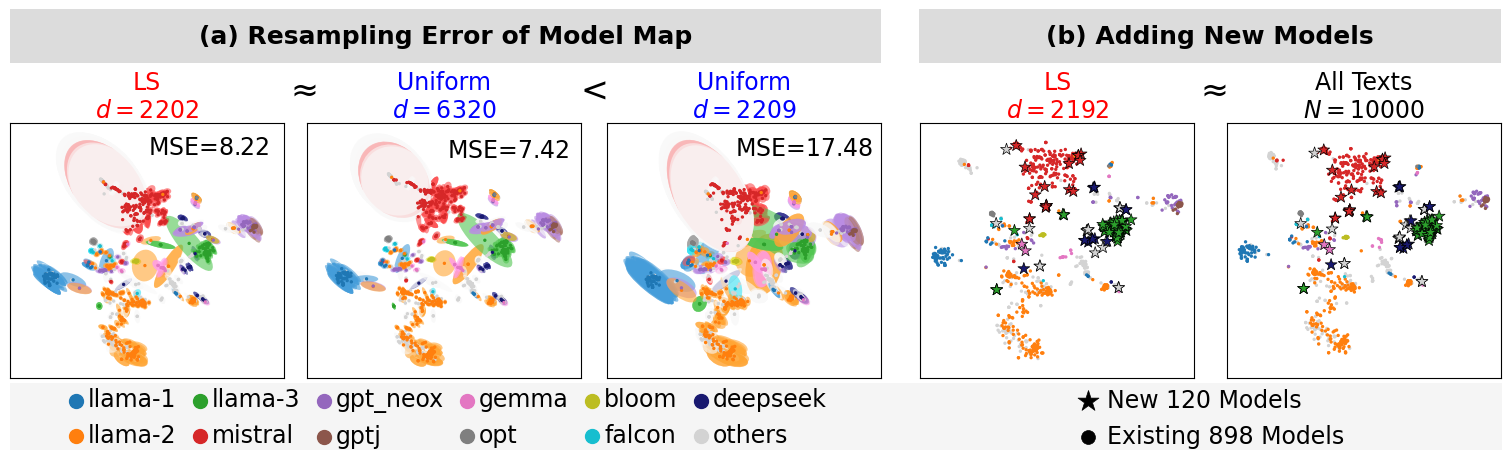

In [7]:
figure = plt.figure(figsize=(15, 4.5))
gs_master = GridSpec(nrows=4, ncols=6, height_ratios=[0.8, 0.52, 2.98, 0.2], width_ratios=[2.98, 2.98, 2.98, 0.01, 2.98, 2.98])
gs_tit1 = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[0, 0:3])
gs_tit2 = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[0, 4:6])
gs_1mpt = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[1, 0])
gs_2mpt = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[1, 1])
gs_3mpt = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[1, 2])
gs_4mpt = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[1, 4])
gs_5mpt = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[1, 5])
gs_map1 = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[2, 0])
gs_map2 = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[2, 1])
gs_map3 = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[2, 2])
gs_map4 = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[2, 4])
gs_map5 = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[2, 5])
gs_spce = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[0:2, 3])
gs_rect = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[3, :])
gs_lgd1 = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[3, 0:3])
gs_lgd2 = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[3, 4:6])

ax_tit1 = figure.add_subplot(gs_tit1[0, 0]); ax_tit1.axis('off')
ax_tit2 = figure.add_subplot(gs_tit2[0, 0]); ax_tit2.axis('off')
ax_1mpt = figure.add_subplot(gs_1mpt[0, 0]); ax_1mpt.axis('off')
ax_2mpt = figure.add_subplot(gs_2mpt[0, 0]); ax_2mpt.axis('off')
ax_3mpt = figure.add_subplot(gs_3mpt[0, 0]); ax_3mpt.axis('off')
ax_4mpt = figure.add_subplot(gs_4mpt[0, 0]); ax_4mpt.axis('off')
ax_5mpt = figure.add_subplot(gs_5mpt[0, 0]); ax_5mpt.axis('off')
ax_map1 = figure.add_subplot(gs_map1[0, 0]); ax_map1.axis('equal')
ax_map2 = figure.add_subplot(gs_map2[0, 0]); ax_map2.axis('equal')
ax_map3 = figure.add_subplot(gs_map3[0, 0]); ax_map3.axis('equal')
ax_map4 = figure.add_subplot(gs_map4[0, 0]); ax_map4.axis('equal')
ax_map5 = figure.add_subplot(gs_map5[0, 0]); ax_map5.axis('equal')
ax_rect = figure.add_subplot(gs_rect[0, 0]); ax_rect.axis('off')
ax_lgd1 = figure.add_subplot(gs_lgd1[0, 0]); ax_lgd1.axis('off')
ax_lgd2 = figure.add_subplot(gs_lgd2[0, 0]); ax_lgd2.axis('off')
ax_spce = figure.add_subplot(gs_spce[0, 0]); ax_spce.axis('off')

# Titles
put_text(ax_tit1, 0.5,    0.5, '(a) Resampling Error of Model Map')
put_text(ax_tit1, 0.333, -0.5, r'$\approx$', fs=24, w='medium')
put_text(ax_tit1, 0.666, -0.5, r'$<$', fs=24, w='medium')
put_text(ax_tit2, 0.5,    0.5, '(b) Adding New Models')
put_text(ax_tit2, 0.5,   -0.5, r'$\approx$', fs=24, w='medium')
put_bg(ax_tit1)
put_bg(ax_tit2)

# Description of each map
map_descriptions = [
    (ax_1mpt, 'LS\n'        + r'$d=2202$',  'red'),
    (ax_2mpt, 'Uniform\n'   + r'$d=6320$',  'blue'),
    (ax_3mpt, 'Uniform\n'   + r'$d=2209$',  'blue'),
    (ax_4mpt, 'LS\n'        + r'$d=2192$',  'red'),
    (ax_5mpt, 'All Texts\n' + r'$N=10000$', 'black')
]
for ax, text, color in map_descriptions:
    put_text(ax, 0.5, 0.5, text, fs=17, w='medium', color=color)

# Plot
scatter_and_ellipse(ax_map1, plot_data1); put_mse(ax_map1, value=8.22)
scatter_and_ellipse(ax_map2, plot_data2); put_mse(ax_map2, value=7.42)
scatter_and_ellipse(ax_map3, plot_data3); put_mse(ax_map3, value=17.48)
scatter_newmodels(ax_map4, plot_data4)
scatter_newmodels(ax_map5, plot_data5)

# Legend
for modeltype_name, color_code in type_color.items():
    handle = ax_lgd1.scatter([], [], s=100, c=[color_code], label=modeltype_name)
ax_lgd2.scatter([], [], s=2.5, c='black', alpha=1, marker='*', edgecolor='black', linewidths=0.5, label='New 120 Models')
ax_lgd2.scatter([], [], s=1.0, c='black', alpha=1, marker='o', edgecolor='black', linewidths=0.5, label='Existing 898 Models')

ax_lgd1.legend(loc='center', fontsize=17, frameon=False, labelspacing=0.5, handlelength=1, handletextpad=0, ncol=6, columnspacing=0.5)
ax_lgd2.legend(loc='center', fontsize=17, frameon=False, labelspacing=0.5, handlelength=1, handletextpad=0.3, ncol=1, markerscale=10)
rect_lg = Rectangle(xy=(0, -3.25), width=1, height=5, facecolor='whitesmoke', linewidth=0, edgecolor='gray', alpha=1, zorder=100, transform=ax_rect.transAxes, clip_on=False)
ax_rect.add_patch(rect_lg)

# adjust
dw_map = 0.05
dh_map = dw_map * 2.5
dy_tit = 0.11

nudges = [
    (ax_map1, (-0.123,  0,      dw_map, dh_map)),
    (ax_1mpt, (-0.123,  dy_tit, dw_map, 0)),
    (ax_map2, (-0.08,   0,      dw_map, dh_map)),
    (ax_2mpt, (-0.08,   dy_tit, dw_map, 0)),
    (ax_map3, (-0.035,  0,      dw_map, dh_map)),
    (ax_3mpt, (-0.035,  dy_tit, dw_map, 0)),
    (ax_map4, (-0.0035, 0,      dw_map, dh_map)),
    (ax_4mpt, (-0.0035, dy_tit, dw_map, 0)),
    (ax_map5, (0.046,   0,      dw_map, dh_map)),
    (ax_5mpt, (0.046,   dy_tit, dw_map, 0)),
    (ax_tit1, (-0.123,  0.113,  0.138,  0)),
    (ax_lgd1, (-0.123, -0.04,   0.138,  0)),
    (ax_tit2, (-0.004,  0.113,  0.1,    0)),
    (ax_lgd2, (-0.004, -0.04,   0.1,    0)),
    (ax_rect, (-0.123,  0,      0.2195, 0)),
]
for ax, (dx, dy, dw, dh) in nudges:
    adjust(ax, dx, dy, dw, dh)

plt.savefig('./figures/fig3.pdf', format='pdf')
plt.savefig('./figures/fig3.png', format='png', dpi=500)
plt.show()